# 05 - Métricas e localização (autoencoder) — metodologia corrigida

Usa o autoencoder treinado para calcular as métricas de localização do enunciado.

> **Correção vs versão antiga:** thresholds (imagem e pixel) calibrados na
> **validação** (não maximizando Dice no teste) e máscaras com interpolação
> **nearest-neighbor** — igual a `scripts/eval_autoencoder_bottle.py`.

## 0. Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.append(str(ROOT / "src"))

import torch
from utils import set_seed, get_device

set_seed(42)
device = get_device()
print("device:", device)

device: cuda


## 1. Carregar autoencoder e calibrar thresholds na validação

In [2]:
from autoencoder import Autoencoder
from bottle_protocol import bottle_train_good_paths, split_train_validation_good, bottle_test_records
from dataset import criar_loader_de_paths
from eval_autoencoder import reconstruction_maps, validation_pixel_errors, flatten_test_masks

modelo = Autoencoder().to(device)
modelo.load_state_dict(torch.load(ROOT / "models" / "autoencoder_bottle_best.pth", map_location=device))
modelo.eval()

train_good = bottle_train_good_paths()
_, val_paths = split_train_validation_good(train_good, val_fraction=0.2, seed=42)
val_loader = criar_loader_de_paths(val_paths, batch_size=16, tamanho_imagem=256, shuffle=False)

val_out = reconstruction_maps(modelo, val_loader, device)
image_threshold = float(np.quantile(val_out["image_scores"], 0.95))
val_pixel = validation_pixel_errors(modelo, val_paths, device=device, image_size=256)
pixel_threshold = float(np.quantile(val_pixel, 0.995))
print(f"Threshold imagem: {image_threshold:.5f} | Threshold pixel: {pixel_threshold:.5f}")

Threshold imagem: 0.01916 | Threshold pixel: 0.28431


## 2. Avaliar no teste (máscaras com nearest-neighbor)

In [3]:
from metrics import binary_classification_metrics, safe_auroc, segmentation_metrics
import json

registos = bottle_test_records()
test_loader = criar_loader_de_paths(
    [r.path for r in registos], labels=[r.label for r in registos],
    tipos=[r.defect_type for r in registos], batch_size=16, tamanho_imagem=256, shuffle=False,
)
test_out = reconstruction_maps(modelo, test_loader, device)

pixel_scores = np.concatenate([m.ravel() for m in test_out["error_maps"]])
pixel_labels = flatten_test_masks(test_out["paths"], size=256)

img_metrics = binary_classification_metrics(test_out["labels"], test_out["image_scores"], image_threshold)
img_metrics["image_auroc"] = safe_auroc(test_out["labels"], test_out["image_scores"])
pix_metrics = segmentation_metrics(pixel_labels, pixel_scores, pixel_threshold)
pix_metrics["pixel_auroc"] = safe_auroc(pixel_labels, pixel_scores)
print("Image-level:", json.dumps(img_metrics, indent=2))
print("Pixel-level:", json.dumps(pix_metrics, indent=2))

Image-level: {
  "threshold": 0.019161180220544336,
  "accuracy": 0.8433734939759037,
  "precision": 0.9310344827586207,
  "recall": 0.8571428571428571,
  "f1": 0.8925619834710744,
  "image_auroc": 0.930952380952381
}
Pixel-level: {
  "pixel_threshold": 0.2843124160170548,
  "pixel_precision": 0.47172314864622555,
  "pixel_recall": 0.08368110336403889,
  "pixel_f1": 0.14214624183447971,
  "iou": 0.07651099620178801,
  "dice": 0.14214624183447971,
  "pixel_auroc": 0.8020156149324816
}


## 3. Distribuição do score de anomalia (normal vs defeito)

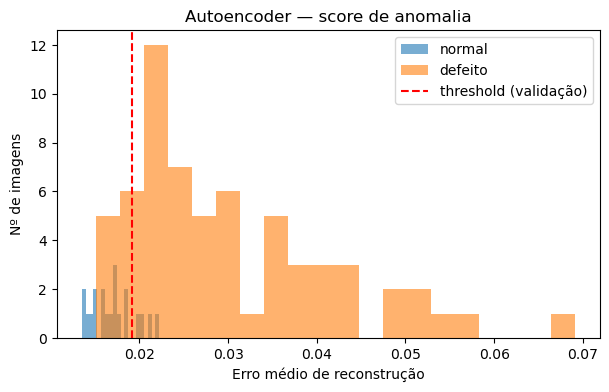

In [4]:
scores = test_out["image_scores"]; labels = test_out["labels"]
plt.figure(figsize=(7, 4))
plt.hist(scores[labels == 0], bins=20, alpha=0.6, label="normal")
plt.hist(scores[labels == 1], bins=20, alpha=0.6, label="defeito")
plt.axvline(image_threshold, color="red", linestyle="--", label="threshold (validação)")
plt.xlabel("Erro médio de reconstrução"); plt.ylabel("Nº de imagens")
plt.title("Autoencoder — score de anomalia"); plt.legend(); plt.show()

## 4. Falsos positivos por categoria (threshold da validação)

In [5]:
tipos = test_out["defect_types"]; scores = test_out["image_scores"]
for cat in ["good", "broken_large", "broken_small", "contamination"]:
    m = tipos == cat; n = int(m.sum())
    det = int((scores[m] >= image_threshold).sum())
    etq = "  <- FALSOS POSITIVOS" if cat == "good" else ""
    print(f"{cat:14s}: {det}/{n} marcadas como defeito{etq}")

good          : 4/20 marcadas como defeito  <- FALSOS POSITIVOS
broken_large  : 20/20 marcadas como defeito
broken_small  : 19/22 marcadas como defeito
contamination : 15/21 marcadas como defeito


## 5. Visualização: original / erro / máscara prevista / máscara real

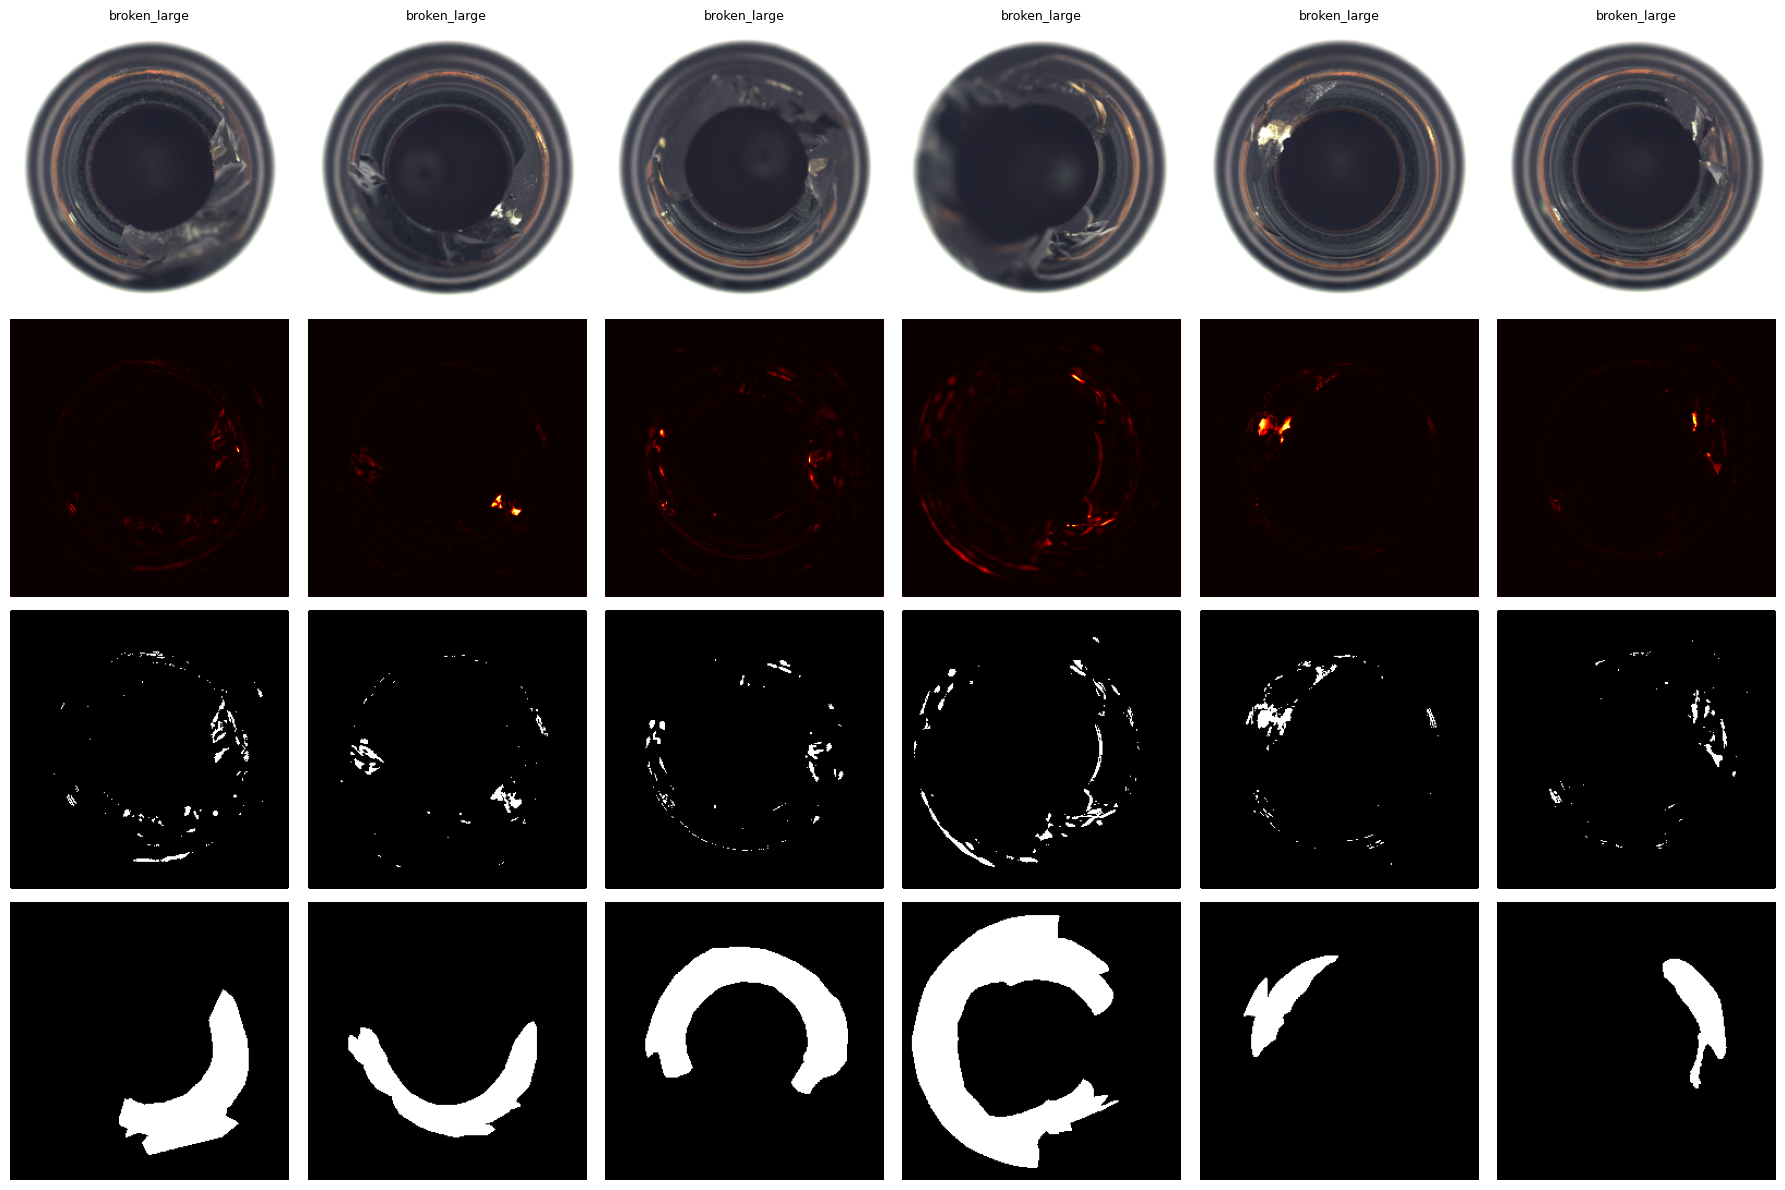

In [6]:
from eval_autoencoder import load_mask_for_path
from PIL import Image

idx_def = [i for i, t in enumerate(test_out["defect_types"]) if t != "good"][:6]
fig, axes = plt.subplots(4, len(idx_def), figsize=(3 * len(idx_def), 12))
linhas = ["Original", "Mapa de erro", "Máscara prevista", "Máscara real"]
for col, i in enumerate(idx_def):
    erro = test_out["error_maps"][i]
    pred = (erro >= pixel_threshold).astype(np.uint8)
    real = load_mask_for_path(test_out["paths"][i], size=256)
    orig = np.array(Image.open(test_out["paths"][i]).convert("RGB").resize((256, 256)))
    axes[0, col].imshow(orig); axes[0, col].set_title(test_out["defect_types"][i], fontsize=9)
    axes[1, col].imshow(erro, cmap="hot")
    axes[2, col].imshow(pred, cmap="gray")
    axes[3, col].imshow(real, cmap="gray")
    for l in range(4):
        axes[l, col].axis("off")
for l, nome in enumerate(linhas):
    axes[l, 0].set_ylabel(nome, fontsize=11)
plt.tight_layout(); plt.show()

## 6. Conclusão

Com a metodologia corrigida (treino → validação → teste, sem leakage), os números
são honestos e reprodutíveis — iguais aos dos scripts. A deteção a nível de
imagem é boa; a **localização ao pixel** é o ponto fraco do autoencoder (ver a
U-Net, no notebook **07_unet**, que localiza muito melhor).